In [10]:
pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]
Note: you may need to restart the kernel to use updated packages.


In [13]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



In [14]:
import pandas as pd

url = "./Mall_Customers.csv"
df = pd.read_csv(url)

print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [15]:
df.isnull().sum()
df["Label"] = (df["Spending Score (1-100)"] > 60).astype(int)
df = df.drop("CustomerID", axis=1)
df["Genre"] = df["Genre"].map({"Male": 0, "Female": 1})

<function matplotlib.pyplot.show(close=None, block=None)>

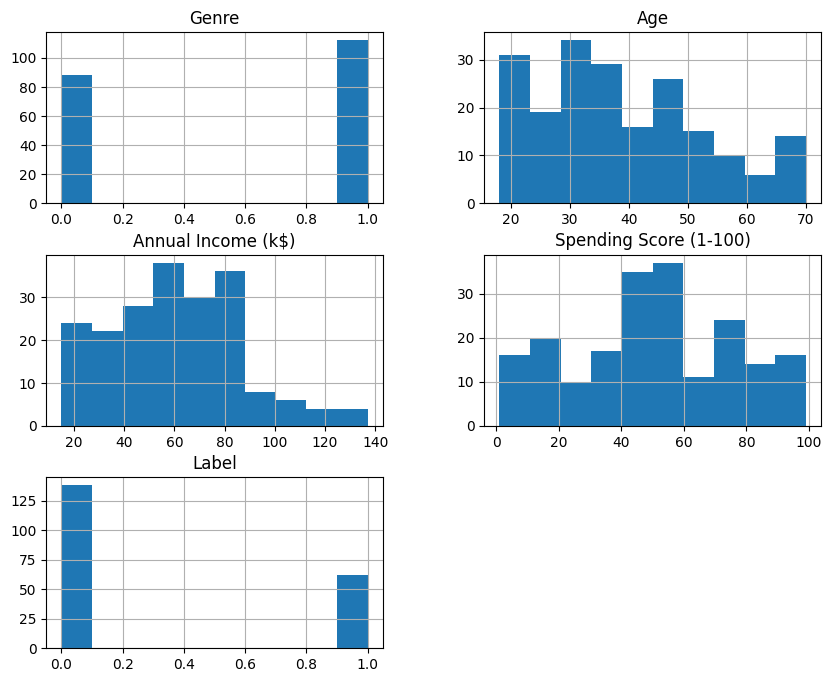

In [6]:
df.hist(figsize=(10, 8))
plt.show


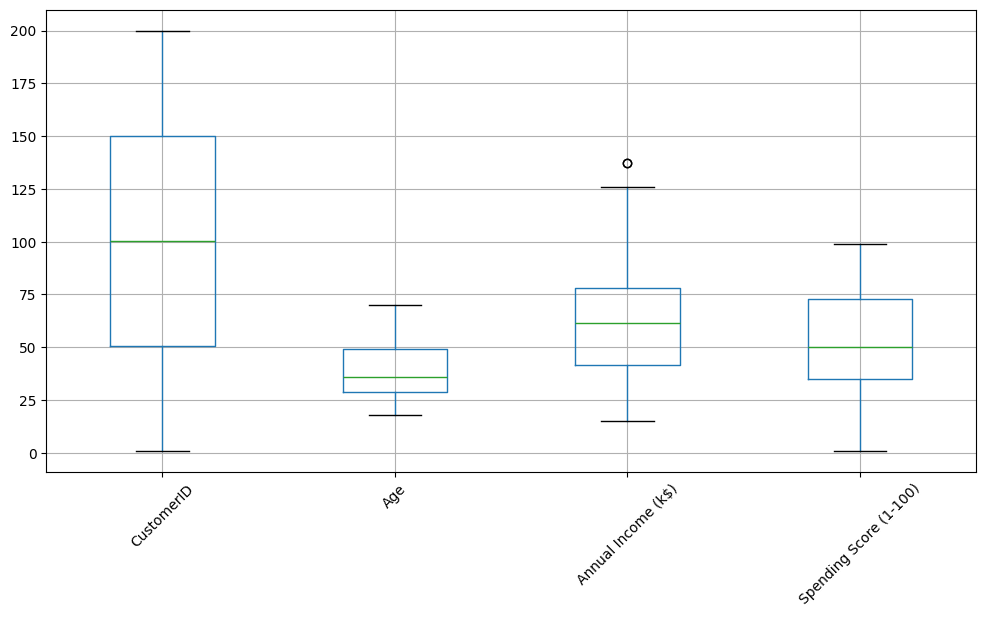

In [20]:
df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

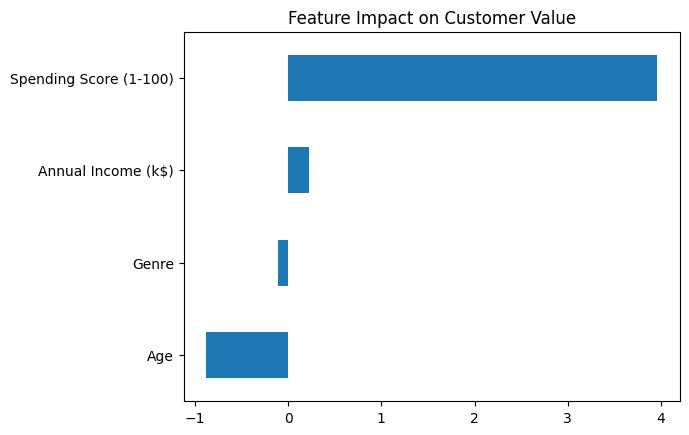

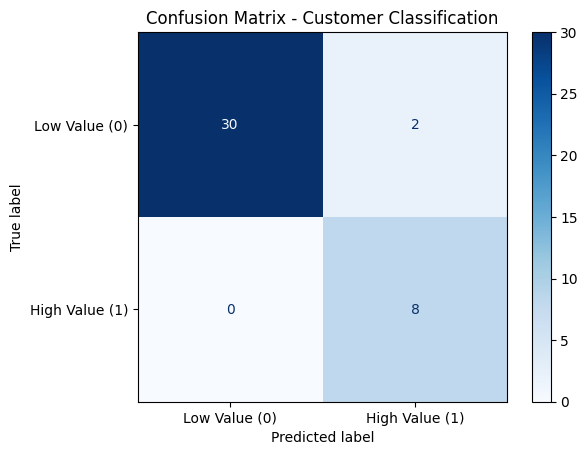

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



# -----------------------------
# FEATURES & TARGET
# -----------------------------
X = df.drop("Label", axis=1)
y = df["Label"]


# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# -----------------------------
# SCALING
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -----------------------------
# MODEL TRAINING
# -----------------------------
model = LogisticRegression()
model.fit(X_train, y_train)


# -----------------------------
# PREDICTIONS
# -----------------------------
y_pred = model.predict(X_test)


# -----------------------------
# EVALUATION
# -----------------------------
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print("\nReport:\n", classification_report(y_test, y_pred))



# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
importance = pd.Series(model.coef_[0], index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Feature Impact on Customer Value")
plt.show()
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Value (0)", "High Value (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Customer Classification")
plt.show()




   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


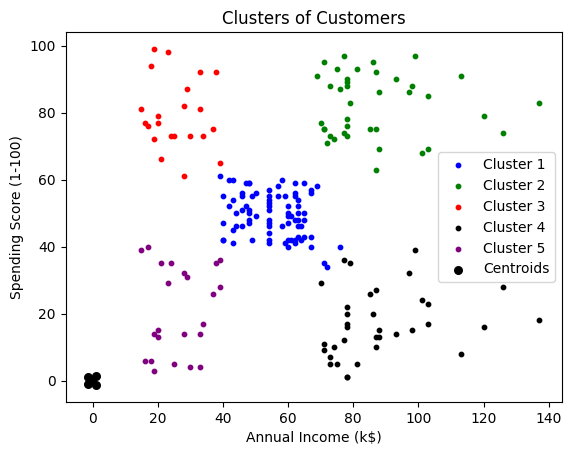

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Import dataset
# -----------------------------
df = pd.read_csv('Mall_Customers.csv')
print(df.head())

# -----------------------------
# Extract features (Annual Income & Spending Score)
# -----------------------------
X = df.iloc[:, [3, 4]].values

# -----------------------------
# Elbow Method to find optimal clusters
# -----------------------------
wcss_list = []

for i in range(1, 20):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss_list.append(kmeans.inertia_)

# Plot Elbow Graph
# plt.plot(range(1, 11), wcss_list)
# plt.title('The Elbow Method Graph')
# plt.xlabel('Number of clusters (k)')
# plt.ylabel('WCSS')
# plt.show()

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Train K-Means Model
# -----------------------------
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_predict = kmeans.fit_predict(X_scaled)

# -----------------------------
# Visualizing Clusters
# -----------------------------
plt.scatter(X[y_predict == 0, 0], X[y_predict == 0, 1],
            s=10, c='blue', label='Cluster 1')

plt.scatter(X[y_predict == 1, 0], X[y_predict == 1, 1],
            s=10, c='green', label='Cluster 2')

plt.scatter(X[y_predict == 2, 0], X[y_predict == 2, 1],
            s=10, c='red', label='Cluster 3')

plt.scatter(X[y_predict == 3, 0], X[y_predict == 3, 1],
            s=10, c='black', label='Cluster 4')

plt.scatter(X[y_predict == 4, 0], X[y_predict == 4, 1],
            s=10, c='purple', label='Cluster 5')

# Centroids (note: these are in scaled space)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=30, c='', label='Centroids')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()